Import Modules

In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob


Load All CSVs

In [2]:

csv_files = glob.glob("memory_pressure_results_*.csv")
df_list = [pd.read_csv(f) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)

df.head()


,pdf_name,memory_mb,status,latency_sec,output_length,partial_output,error_type,batch_id
0,Marathi_BLOOD_normal_4.pdf,1024,success,23.754047,1311,False,NaN,1
1,Bengali_LIVER_normal_1.pdf,1024,success,38.079465,2771,False,NaN,1
2,Spanish_KIDNEY_normal_2.pdf,1024,success,18.429609,1418,False,NaN,1
3,French_KIDNEY_abnormal_1.pdf,1024,success,30.061134,2210,False,NaN,1
4,French_KIDNEY_abnormal_3.pdf,1024,success,20.136742,1573,False,NaN,1


Success vs Failure

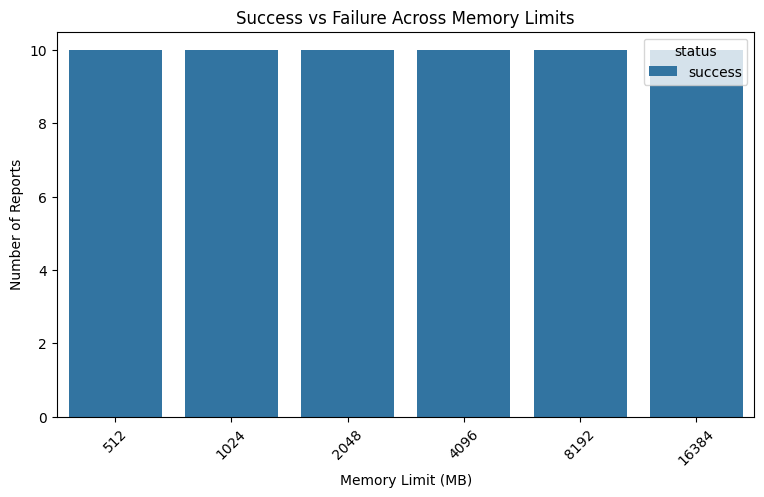

In [3]:

plt.figure(figsize=(9,5))
sns.countplot(data=df, x="memory_mb", hue="status")
plt.title("Success vs Failure Across Memory Limits")
plt.xlabel("Memory Limit (MB)")
plt.ylabel("Number of Reports")
plt.xticks(rotation=45)
plt.show()


 Latency Distribution

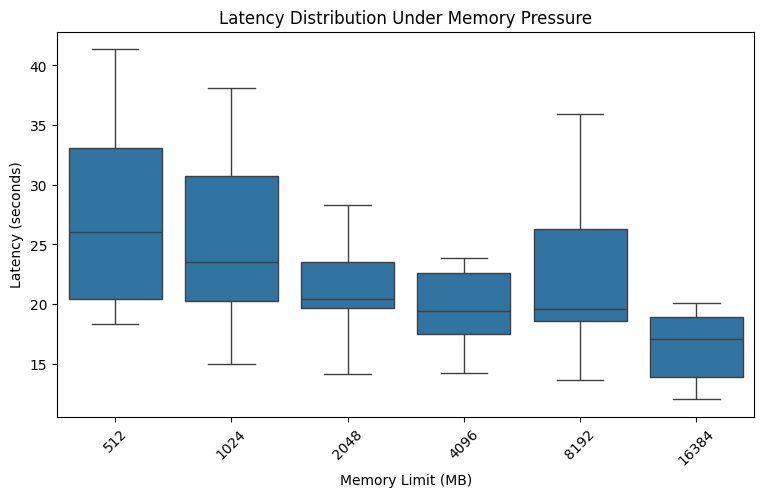

In [4]:

plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="memory_mb", y="latency_sec")
plt.title("Latency Distribution Under Memory Pressure")
plt.xlabel("Memory Limit (MB)")
plt.ylabel("Latency (seconds)")
plt.xticks(rotation=45)
plt.show()


 Partial Output Fraction

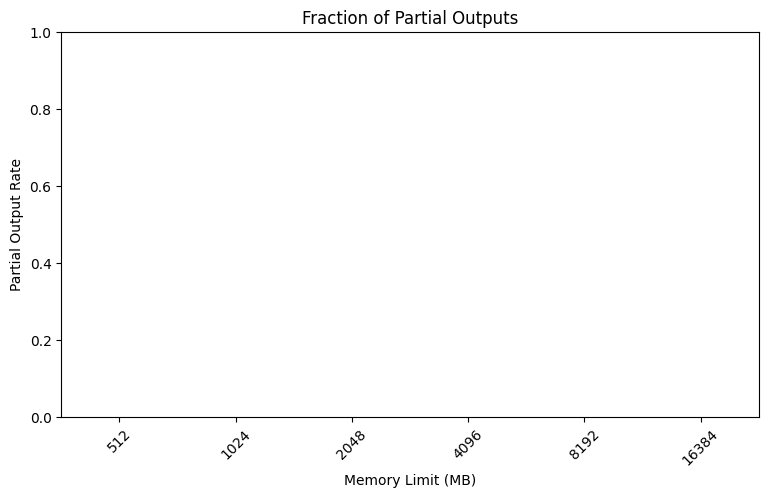

In [5]:

successful = df[df["status"] == "success"]

plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=successful,
    x="memory_mb",
    y="partial_output",
    estimator=lambda x: sum(x)/len(x)
)

ax.set_ylim(0, 1)
plt.title("Fraction of Partial Outputs")
plt.xlabel("Memory Limit (MB)")
plt.ylabel("Partial Output Rate")
plt.xticks(rotation=45)
plt.show()
